In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/CPE_KMUTT/Year3/Semester_1-68/CPE342_MachineLearning/CPE342_Lab/CPE342_Lab_Assignment4_Tree-basedAndEnsembleModels/MBA.csv")
df

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN
...,...,...,...,...,...,...,...,...,...,...
6189,6190,Male,False,3.49,Business,White,640.0,5.0,Other,NaN
6190,6191,Male,False,3.18,STEM,Black,670.0,4.0,Consulting,NaN
6191,6192,Female,True,3.22,Business,NaN,680.0,5.0,Health Care,Admit
6192,6193,Male,True,3.36,Business,NaN,590.0,5.0,Other,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [ ]:
# Drop the application_id column
df = df.drop('application_id', axis=1)

# Fill missing values in 'race' with the mode
df['race'] = df['race'].fillna(df['race'].mode()[0])

# Drop rows with missing values in 'admission'
df = df.dropna(subset=['admission'])

In [ ]:
df

,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
2,Female,True,3.30,Business,White,710.0,5.0,Technology,Admit
6,Female,False,2.93,STEM,Other,590.0,3.0,Technology,Admit
12,Female,False,3.24,Humanities,Hispanic,640.0,6.0,PE/VC,Waitlist
14,Female,False,3.03,STEM,White,600.0,5.0,Technology,Admit
...,...,...,...,...,...,...,...,...,...
6152,Female,False,3.31,Business,Black,690.0,3.0,Other,Admit
6168,Female,False,3.21,STEM,White,680.0,5.0,Consulting,Admit
6175,Female,False,3.38,Humanities,Hispanic,680.0,3.0,Technology,Admit
6177,Male,False,3.35,Humanities,Hispanic,750.0,5.0,PE/VC,Admit


convert a column of object (string) data into numerical representations
* `.astype('category')`: This part converts the column's data type to 'category'. Pandas will identify the unique values in the column and treat them as distinct categories.
* `.cat`: This accesses the .cat accessor, which provides special methods for categorical data.
* `.codes`: This is a property of the .cat accessor that returns a NumPy array of integer codes for each value in the categorical series. Each unique category is assigned a unique integer code.

In [ ]:
for col in df.select_dtypes(include=['object', 'bool']).columns:
    # Mapping of unique values to codes
    category_mapping = dict(enumerate(df[col].astype('category').cat.categories))
    df[col] = df[col].astype('category').cat.codes
    print(f"Mapping for column '{col}':")
    print(category_mapping, '\n')
df

Mapping for column 'gender':
{0: 'Female', 1: 'Male'} 

Mapping for column 'international':
{0: False, 1: True} 

Mapping for column 'major':
{0: 'Business', 1: 'Humanities', 2: 'STEM'} 

Mapping for column 'race':
{0: 'Asian', 1: 'Black', 2: 'Hispanic', 3: 'Other', 4: 'White'} 

Mapping for column 'work_industry':
{0: 'CPG', 1: 'Consulting', 2: 'Energy', 3: 'Financial Services', 4: 'Health Care', 5: 'Investment Banking', 6: 'Investment Management', 7: 'Media/Entertainment', 8: 'Nonprofit/Gov', 9: 'Other', 10: 'PE/VC', 11: 'Real Estate', 12: 'Retail', 13: 'Technology'} 

Mapping for column 'admission':
{0: 'Admit', 1: 'Waitlist'} 



,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,0,0,3.30,0,0,620.0,3.0,3,0
2,0,1,3.30,0,4,710.0,5.0,13,0
6,0,0,2.93,2,3,590.0,3.0,13,0
12,0,0,3.24,1,2,640.0,6.0,10,1
14,0,0,3.03,2,4,600.0,5.0,13,0
...,...,...,...,...,...,...,...,...,...
6152,0,0,3.31,0,1,690.0,3.0,9,0
6168,0,0,3.21,2,4,680.0,5.0,1,0
6175,0,0,3.38,1,2,680.0,3.0,13,0
6177,1,0,3.35,1,2,750.0,5.0,10,0


In [ ]:
# Separate the feature columns from the target column
features = df.drop('admission', axis=1)
target = df['admission']

print(features)
print(target)

      gender  international   gpa  major  race   gmat  work_exp  work_industry
0          0              0  3.30      0     0  620.0       3.0              3
2          0              1  3.30      0     4  710.0       5.0             13
6          0              0  2.93      2     3  590.0       3.0             13
12         0              0  3.24      1     2  640.0       6.0             10
14         0              0  3.03      2     4  600.0       5.0             13
...      ...            ...   ...    ...   ...    ...       ...            ...
6152       0              0  3.31      0     1  690.0       3.0              9
6168       0              0  3.21      2     4  680.0       5.0              1
6175       0              0  3.38      1     2  680.0       3.0             13
6177       1              0  3.35      1     2  750.0       5.0             10
6191       0              1  3.22      0     4  680.0       5.0              4

[1000 rows x 8 columns]
0       0
2       0
6      

# Decision Tree

In [ ]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Create and train a Decision Tree model with entropy criterion
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)

# train the model
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
accuracy = (y_pred == y_test).mean()
print(f"Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 81.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       178
           1       0.20      0.23      0.21        22

    accuracy                           0.81       200
   macro avg       0.55      0.56      0.55       200
weighted avg       0.83      0.81      0.82       200


Confusion Matrix:
[[158  20]
 [ 17   5]]


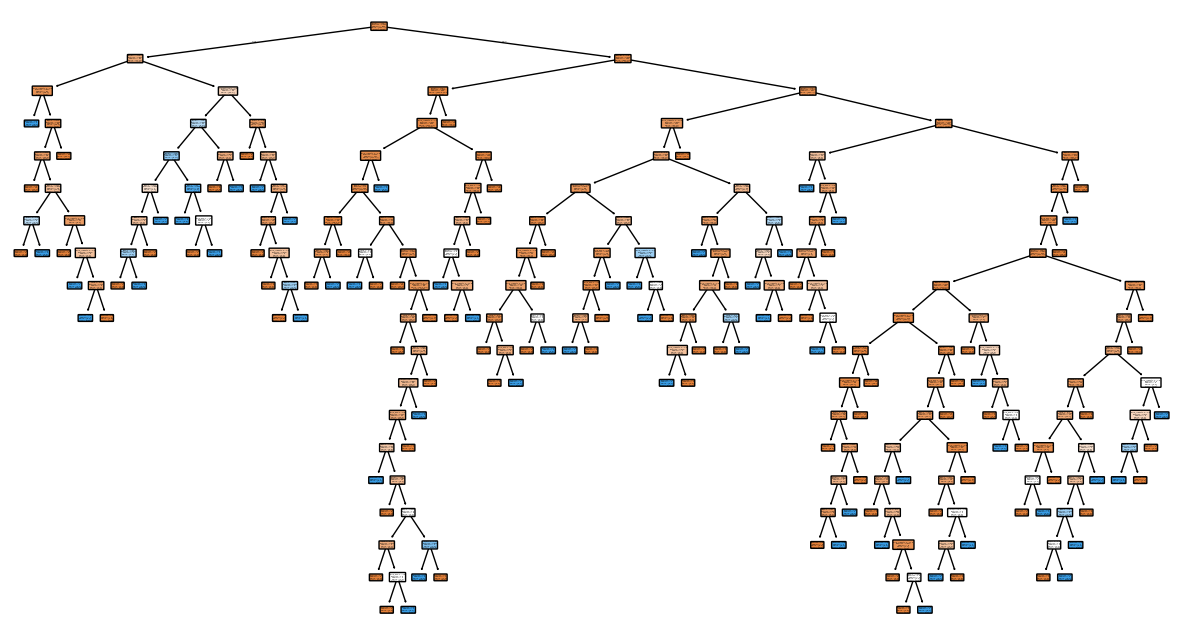

In [ ]:
plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=features.columns, class_names=['Admit', 'Waitlist'], filled=True, rounded=True)
plt.show()

# Random Forest

The classification reports for both the Random Forest and Gradient Boosting models show precision, recall, and f1-score of 0 for the 'Waitlist' class. This is likely due to the dataset being imbalanced, where the 'Admit' class is much more frequent than the 'Waitlist' class. The models are predicting the majority class ('Admit') for all instances, resulting in no correct predictions for the 'Waitlist' class. I will add `zero_division=0` to the `classification_report` to avoid the warning and explicitly show the 0 values for the 'Waitlist' class metrics.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create and train a Random Forest model
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_clf.predict(X_test)

# Classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       178
           1       0.00      0.00      0.00        22

    accuracy                           0.89       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.79      0.89      0.84       200



# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# Create and train a Gradient Boosting model
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_clf.predict(X_test)

# Classification report
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       178
           1       0.00      0.00      0.00        22

    accuracy                           0.88       200
   macro avg       0.44      0.49      0.47       200
weighted avg       0.79      0.88      0.83       200

